# V3: Final Evaluation
This notebook compares the frozen fair V1, V2, and V3 models on the common test split. The split was evaluated during the original V1 phase, while V2 and V3 model and checkpoint decisions used only the validation set. No model changes were made after this comparison.

## 3.1 V1 Evaluation

Accuracy: 0.7068
Classes: ['assignment' 'call' 'control_flow' 'expression' 'identifier']
Confusion Matrix:
[[ 692  157   19   46    3]
 [ 118 3065   28  208   15]
 [  35   54  925   62    3]
 [ 347  743   76  307   10]
 [  66   84    6   10   50]]
              precision    recall  f1-score   support

  assignment     0.5501    0.7546    0.6363       917
        call     0.7470    0.8925    0.8133      3434
control_flow     0.8776    0.8573    0.8673      1079
  expression     0.4850    0.2070    0.2902      1483
  identifier     0.6173    0.2315    0.3367       216

    accuracy                         0.7068      7129
   macro avg     0.6554    0.5886    0.5888      7129
weighted avg     0.6830    0.7068    0.6755      7129



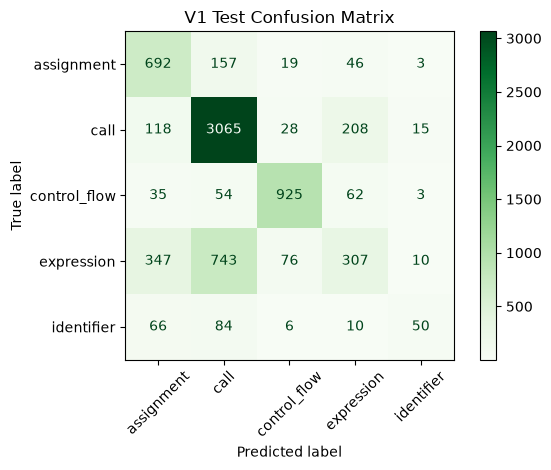

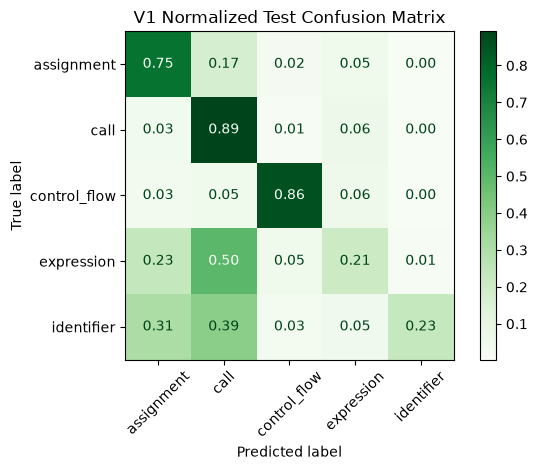

In [1]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import joblib

# V1 Model
v1_model = joblib.load('models/logistic_regression_v1_no_validation.joblib')
v1_vectorizer = joblib.load('models/tfidf_vectorizer_v1_no_validation.joblib')

# V1 Testset
v1_test = pd.read_csv('data/processed/test.csv')
v1_test_truth_label = v1_test['top_level_label']

#V1 Predictions and Evaluation
v1_test_features = v1_vectorizer.transform(v1_test["diff"])
v1_predictions = v1_model.predict(v1_test_features)

v1_accuracy = accuracy_score(v1_test_truth_label, v1_predictions)
print(f"Accuracy: {v1_accuracy:.4f}")
v1_macro_f1 = f1_score(v1_test_truth_label, v1_predictions, average='macro')

v1_weighted_f1 = f1_score(v1_test_truth_label, v1_predictions, average='weighted')

#Confusion Matrix
v1_cf_mat = confusion_matrix(v1_test_truth_label, v1_predictions, labels=v1_model.classes_)
print("Classes:", v1_model.classes_)
print("Confusion Matrix:")
print(v1_cf_mat)

v1_report = classification_report(v1_test_truth_label, v1_predictions, labels=v1_model.classes_, digits=4, zero_division=0)
print(v1_report)

v1_cm_display = ConfusionMatrixDisplay(confusion_matrix=v1_cf_mat, display_labels=v1_model.classes_)

v1_cm_display.plot(cmap='Greens', values_format='d')
plt.xticks(rotation=45)
plt.title('V1 Test Confusion Matrix')
plt.tight_layout()
plt.show()

v1_normalized_confusion = confusion_matrix(v1_test_truth_label, v1_predictions, labels=v1_model.classes_, normalize='true')

v1_cm_display = ConfusionMatrixDisplay(confusion_matrix=v1_normalized_confusion, display_labels=v1_model.classes_)

v1_cm_display.plot(cmap='Greens', values_format='.2f')
plt.xticks(rotation=45)
plt.title('V1 Normalized Test Confusion Matrix')
plt.tight_layout()
plt.show()

## 3.2 V2 Evaluation

Best Epoch: 13
Best Validation Loss: 0.5283811876131279
{'0': 'assignment', '1': 'call', '2': 'control_flow', '3': 'expression', '4': 'identifier'}

              precision    recall  f1-score   support

  assignment     0.7447    0.7252    0.7348       917
        call     0.8218    0.8593    0.8401      3434
control_flow     0.8772    0.9073    0.8920      1079
  expression     0.5896    0.5523    0.5703      1483
  identifier     0.6643    0.4306    0.5225       216

    accuracy                         0.7725      7129
   macro avg     0.7395    0.6949    0.7120      7129
weighted avg     0.7672    0.7725    0.7687      7129



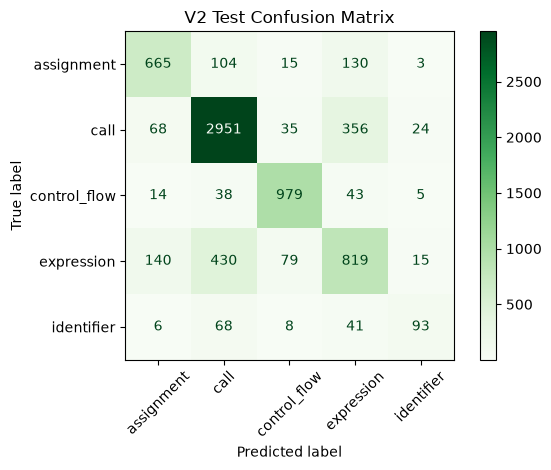

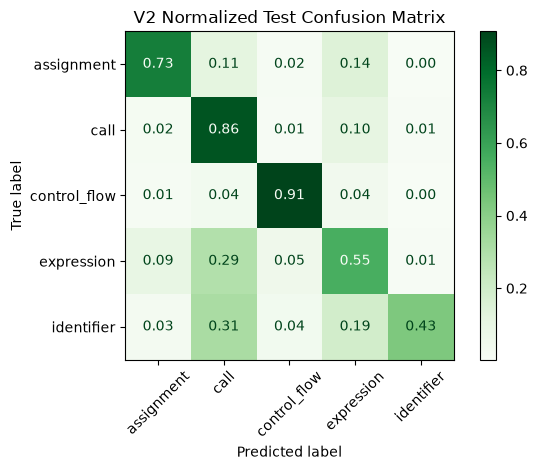

In [2]:
from src.v2.train import BugFixClassifier
from torch.utils.data import DataLoader
from src.v2.data import BugFixDataset, collate_batch
from src.v2.tokenize_diff import tokenize_diff
from src.v2.ids_and_tokens import tokens_to_ids
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from src.v2.evaluate import evaluate_model
import matplotlib.pyplot as plt
import torch
import pandas as pd
import torch.nn as nn
import json

with open('data/processed/token_to_id.json', 'r') as f:
    token_to_id = json.load(f)

with open('data/processed/label_to_id.json', 'r') as f:
    label_to_id = json.load(f)

#V2 Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
v2_model = BugFixClassifier(vocab_size=len(token_to_id), embedding_dimension=128, num_classes=len(label_to_id), padding_index=token_to_id['<PAD>'])
v2_criterion = nn.CrossEntropyLoss()

v2_checkpoint = torch.load('models/v2_best_model.pt', map_location=device, weights_only=True)
v2_model.load_state_dict(v2_checkpoint['model_state_dict'])
v2_epoch = v2_checkpoint['epoch']
v2_loss = v2_checkpoint['validation_loss']

v2_best_epoch = v2_checkpoint['epoch']
v2_best_validation_loss = v2_checkpoint['validation_loss']

print(f'Best Epoch: {v2_best_epoch}')
print(f'Best Validation Loss: {v2_best_validation_loss}')

#V2/3 Testset
test = pd.read_csv('data/processed/test.csv')

test['tokens'] = test['diff'].apply(tokenize_diff)
test['tokens_ids'] = test['tokens'].apply(lambda row_tokens: tokens_to_ids(row_tokens, token_to_id))
test['label_id'] = test['top_level_label'].map(label_to_id)

#Saving the Test V2/V3 Dataset
test.to_parquet('data/processed/test_v2_v3_label_id.parquet', index=False)

test_dataset = BugFixDataset(pd.read_parquet('data/processed/test_v2_v3_label_id.parquet'))
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_batch)

#V2 Evaluation
v2_accuracy, v2_average_loss, v2_all_predictions, v2_all_labels = evaluate_model(v2_model, v2_criterion, test_loader)

with open('data/processed/id_to_label.json', 'r') as file:
    id_to_label = json.load(file)

print(id_to_label)
print()

v2_class_names = [id_to_label[str(i)] for i in range(len(id_to_label))]
print(classification_report(v2_all_labels, v2_all_predictions, target_names=v2_class_names, digits=4))

v2_confusion = confusion_matrix(v2_all_labels, v2_all_predictions, labels=range(len(v2_class_names)))
v2_cm_display = ConfusionMatrixDisplay(confusion_matrix=v2_confusion, display_labels=v2_class_names)

v2_cm_display.plot(cmap='Greens', values_format='d')
plt.xticks(rotation=45)
plt.title('V2 Test Confusion Matrix')
plt.tight_layout()
plt.show()

v2_normalized_confusion = confusion_matrix(v2_all_labels, v2_all_predictions, labels=range(len(v2_class_names)), normalize='true')

v2_normalized_cm_display = ConfusionMatrixDisplay(confusion_matrix=v2_normalized_confusion, display_labels=v2_class_names)

v2_normalized_cm_display.plot(cmap='Greens', values_format='.2f')
plt.xticks(rotation=45)
plt.title('V2 Normalized Test Confusion Matrix')
plt.tight_layout()
plt.show()


## 3.3 V3 Evaluation

Best Epoch: 10
Best Validation Loss: 0.314357266020779


c:\Program Files\Python312\Lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:181.)
  output = torch._nested_tensor_from_mask(


{'0': 'assignment', '1': 'call', '2': 'control_flow', '3': 'expression', '4': 'identifier'}

              precision    recall  f1-score   support

  assignment     0.8043    0.8648    0.8334       917
        call     0.8933    0.9333    0.9128      3434
control_flow     0.9222    0.9666    0.9439      1079
  expression     0.8370    0.7168    0.7722      1483
  identifier     0.8766    0.6250    0.7297       216

    accuracy                         0.8752      7129
   macro avg     0.8667    0.8213    0.8384      7129
weighted avg     0.8740    0.8752    0.8725      7129



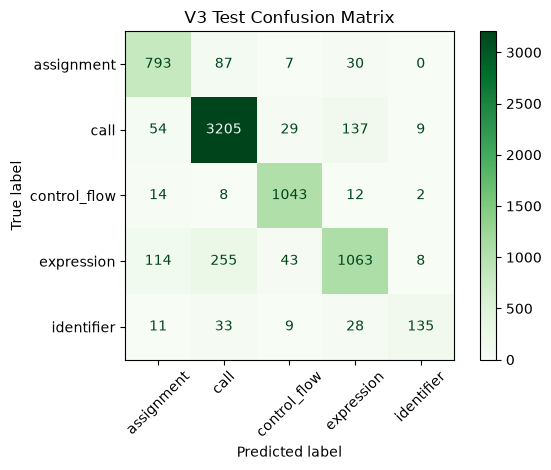

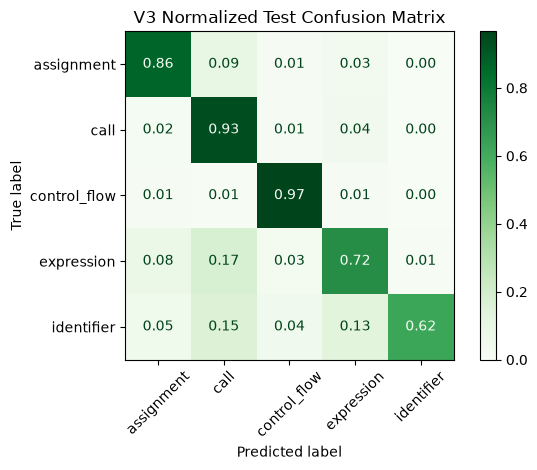

In [3]:
from src.v3.model import TransformerBugFixClassifier
#V3 Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
v3_model = TransformerBugFixClassifier(vocab_size=len(token_to_id), embedding_dim=128, num_heads=4, num_layers=2, feedforward_dim=256, num_classes=len(label_to_id), max_length=1024, padding_index=token_to_id['<PAD>'],dropout=.1).to(device)
v3_criterion = nn.CrossEntropyLoss()

v3_checkpoint = torch.load('models/v3_best_model.pt', map_location=device, weights_only=True)
v3_model.load_state_dict(v3_checkpoint['model_state_dict'])
v3_epoch = v3_checkpoint['epoch']
v3_loss = v3_checkpoint['validation_loss']

v3_best_epoch = v3_checkpoint['epoch']
v3_best_validation_loss = v3_checkpoint['validation_loss']

print(f'Best Epoch: {v3_best_epoch}')
print(f'Best Validation Loss: {v3_best_validation_loss}')

#V3 Evaluation
v3_accuracy, v3_average_loss, v3_all_predictions, v3_all_labels = evaluate_model(v3_model, v3_criterion, test_loader)

print(id_to_label)
print()

v3_class_names = [id_to_label[str(i)] for i in range(len(id_to_label))]
print(classification_report(v3_all_labels, v3_all_predictions, target_names=v3_class_names, digits=4))

v3_confusion = confusion_matrix(v3_all_labels, v3_all_predictions, labels=range(len(v3_class_names)))
v3_cm_display = ConfusionMatrixDisplay(confusion_matrix=v3_confusion, display_labels=v3_class_names)

v3_cm_display.plot(cmap='Greens', values_format='d')
plt.xticks(rotation=45)
plt.title('V3 Test Confusion Matrix')
plt.tight_layout()
plt.show()

v3_normalized_confusion = confusion_matrix(v3_all_labels, v3_all_predictions, labels=range(len(v3_class_names)), normalize='true')

v3_normalized_cm_display = ConfusionMatrixDisplay(confusion_matrix=v3_normalized_confusion, display_labels=v3_class_names)

v3_normalized_cm_display.plot(cmap='Greens', values_format='.2f')
plt.xticks(rotation=45)
plt.title('V3 Normalized Test Confusion Matrix')
plt.tight_layout()
plt.show()


## 3.4 Overall Comparison

In [4]:
from sklearn.metrics import f1_score

v3_macro_f1 = f1_score(v3_all_labels, v3_all_predictions, average='macro')
v3_weighted_f1 = f1_score(v3_all_labels, v3_all_predictions, average='weighted')

v2_macro_f1 = f1_score(v2_all_labels, v2_all_predictions, average='macro')
v2_weighted_f1 = f1_score(v2_all_labels, v2_all_predictions, average='weighted')

v1_macro_f1 = f1_score(v1_test_truth_label, v1_predictions, average='macro')
v1_weighted_f1 = f1_score(v1_test_truth_label, v1_predictions, average='weighted')

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro F1', 'Weighted F1'],
    'V1': [v1_accuracy, v1_macro_f1, v1_weighted_f1],
    'V2': [v2_accuracy, v2_macro_f1, v2_weighted_f1],
    'V3': [v3_accuracy, v3_macro_f1, v3_weighted_f1]
})

comparison['V2 - V1 (pp)'] = (comparison['V2'] - comparison['V1']) * 100
comparison['V3 - V2 (pp)'] = (comparison['V3'] - comparison['V2']) * 100
comparison['V3 - V1 (pp)'] = (comparison['V3'] - comparison['V1']) * 100

display(comparison.round(4))

,Metric,V1,V2,V3,V2 - V1 (pp),V3 - V2 (pp),V3 - V1 (pp)
0,Accuracy,0.7068,0.7725,0.8752,6.5647,10.2679,16.8327
1,Macro F1,0.5888,0.7120,0.8384,12.3189,12.6471,24.9660
2,Weighted F1,0.6755,0.7687,0.8725,9.3236,10.3838,19.7074


## 3.5 Conclusion
V3 achieved the best overall test performance, reaching **87.52%** accuracy, **0.8384** macro F1, and **0.8725** weighted F1. It improved on V2 across every class, with the largest F1 gains occurring for `expression` and `identifier`. These were the classes that were expected to benefit most from preserving token order and learning relationships between tokens. V3’s test results were also very close to its validation results, showing that its performance remained stable on examples excluded from model training. However, `identifier` recall remained at **0.6250**, showing that the model still has difficulty identifying some examples from the smallest class. Overall, the results strongly support the hypothesis that, under this experimental setup, a sequence-aware Transformer representation is more effective than TF-IDF or mean-pooled token embeddings for this classification task.